In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn import svm

sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_excel('data/mobile-info.xlsx') 
df.head()

,Product_Name,Seller_Name,Overall_Rating,Overall_Review,Seller_Rating,Average_Rating,Product_Quality
0,RedmiNote6Pro,FlashstarCommerce,352708,32857,4.7,4.4,Excellent
1,RedmiNote6Pro,SuperComNet,352708,32857,4.3,4.1,Excellent
2,RedmiNote7,SuperComNet,10387,1057,4.3,4.6,Excellent
3,RedmiY1,samaymobiles,17421,1634,3.1,3.7,Good
4,RedmiNote6Pro,FlashstarCommerce,72964,7073,4.3,4.3,Excellent


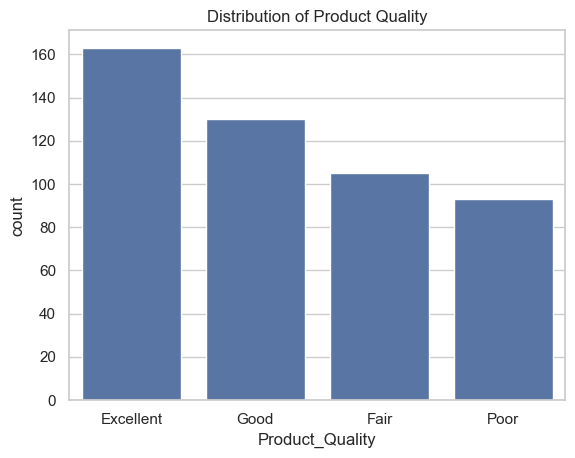

,Product_Name,Seller_Name,Overall_Rating,Overall_Review,Seller_Rating,Average_Rating,Product_Quality
0,11,16,96,87,29,30,0
1,77,7,96,87,25,27,0
2,78,7,62,40,25,32,0
3,79,14,71,45,15,24,2


In [8]:
# Visualize the target variable
sns.countplot(x=df['Product_Quality'])
plt.title("Distribution of Product Quality")
plt.show()

# Initialize Encoder
lab_enc = LabelEncoder()

# Encoding specific columns
df['Product_Name'] = lab_enc.fit_transform(df['Product_Name'])
df['Seller_Name'] = lab_enc.fit_transform(df['Seller_Name'])
df['Product_Quality'] = lab_enc.fit_transform(df['Product_Quality'])

# Categorical encoding for ratings and reviews
df['Seller_Rating'] = df['Seller_Rating'].astype('category').cat.codes
df['Average_Rating'] = df['Average_Rating'].astype('category').cat.codes
df['Overall_Review'] = df['Overall_Review'].astype('category').cat.codes
df['Overall_Rating'] = df['Overall_Rating'].astype('category').cat.codes

df.head(4)

In [9]:
# Select features based on your head(2) output
feature_cols = ['Seller_Name', 'Seller_Rating', 'Overall_Review', 'Overall_Rating', 'Average_Rating']

X = df[feature_cols]
y = df['Product_Quality']

# Split data: 80% for training, 20% for testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

Training set size: 392
Testing set size: 99


In [10]:
# Initialize the SVM Classifier
# 'rbf' is the Radial Basis Function kernel
clf = svm.SVC(kernel='rbf', gamma='auto')

# Train the model
clf.fit(x_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(x_test)

# Display Results
print("--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Evaluation ---
Accuracy Score: 0.90

Confusion Matrix:
[[30  0  0  0]
 [ 2 18  0  0]
 [ 8  0 19  0]
 [ 0  0  0 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        30
           1       1.00      0.90      0.95        20
           2       1.00      0.70      0.83        27
           3       1.00      1.00      1.00        22

    accuracy                           0.90        99
   macro avg       0.94      0.90      0.91        99
weighted avg       0.92      0.90      0.90        99

